# SPX Local Volatility and Delta Hedging

This project studies whether a fitted local-volatility model improves SPX option
hedging relative to Black delta. It combines daily Andreasen–Huge (AH)
calibration, alternative smile-based hedge rules and an empirical
minimum-variance correction.

The analysis covers three parts:

- daily surface fits and numerical diagnostics
- historical hedge errors under consistent funding and execution assumptions
- controlled Black–Scholes and CEV simulations with known prices and Greeks

The historical study covers 2013–2023 and is still running. Its daily models and
hedge summaries are saved in separate stages, so the results below reflect the
scope shown in the loading table.

### Saved Results

The paths in the next cell point to the existing historical and simulation
outputs, the September and October pilots, and the expanded October strategy
comparison. This notebook reads those outputs without starting a new run. Rerunning
the loading cell refreshes the saved-date counts and, when an active run is
found, estimates the remaining daily-model time from recent completion times.
Hedge-path evaluation follows that pass and takes additional time.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown
from results import StudyResults, PilotResults, SimulationResults
from artifacts import PinnedInputs, require, sha256


In [2]:
# Read the original checkout while its frozen historical study runs.
ORIGINAL_REPO = Path("/Users/pranayvij/GitHub/local-vol-spx")
STUDY_FOLDER = ORIGINAL_REPO / "outputs/historical_evaluation/full_2013_2023_v1"
SIMULATION_FOLDER = ORIGINAL_REPO / "outputs/known_model_hedging/run_20261008T094732_825260Z"

# Explicit saved studies; edit these paths if a run was saved elsewhere.
PILOT_INDEXES = {
    "2023-09": ORIGINAL_REPO / "outputs/research_pipeline/september_checkpoint_v1/run_index.json",
    "2023-10": ORIGINAL_REPO / "outputs/research_pipeline/october_full_v1/run_index.json",
}
STRATEGY_MONTH = "2023-10"
STRATEGY_FOLDER = ORIGINAL_REPO / "outputs/optimal_hedging/2023-10/run_20261008T070649_350768Z"

study = StudyResults(STUDY_FOLDER) if (STUDY_FOLDER / "run_index.json").exists() else None
simulation = SimulationResults(SIMULATION_FOLDER) if (SIMULATION_FOLDER / "frequency_summary.csv").exists() else None
pilots = {
    month: PilotResults(index, month, ORIGINAL_REPO).load()
    for month, index in PILOT_INDEXES.items() if index.exists()
}
strategy_reader = None
strategy_audit = None
if (STRATEGY_FOLDER / "audit.json").exists():
    strategy_reader = PinnedInputs(STRATEGY_FOLDER / "audit.json", ORIGINAL_REPO)
    strategy_audit = strategy_reader.read_json(strategy_reader.index_file)
    if strategy_audit.get("month") != STRATEGY_MONTH or strategy_audit.get("status") != "completed":
        raise ValueError("Choose a completed strategy run for STRATEGY_MONTH.")
    upstream = PILOT_INDEXES.get(STRATEGY_MONTH)
    if upstream is not None and upstream.exists():
        digest = sha256(upstream)
        strategy_reader.inputs[str(upstream.resolve())] = digest
        if digest not in strategy_audit.get("input_sha256", {}).values():
            raise ValueError("Strategy results do not pin the selected monthly pilot index.")
    else:
        print("The strategy output checksums can be checked, but the selected upstream pilot index is unavailable.")

summary_audit = None
status_rows = []
if study:
    latest_date = study.dates[-1] if study.dates else "none"
    run_finished = study.index.get("status") == "execution_complete"
    total_dates = None
    calendar_file = study.folder / "calendar_support.csv"
    if calendar_file.exists():
        calendar = pd.read_csv(calendar_file, dtype={"quote_date": str})
        reference = calendar.reference_session.astype(str).str.lower().eq("true")
        total_dates = int((reference & calendar.quote_date.between(study.index["start"], study.index["end"])).sum())
    status_rows.append({"Section": "Daily decisions", "Status": "History complete" if run_finished else "Partial history", "Saved scope": f"{len(study.dates):,} of {total_dates:,} reference dates; latest {latest_date}" if total_dates else f"{len(study.dates):,} dates; latest {latest_date}"})
    if study.summary_ready:
        summary_audit = study.read_json(study.summary / "audit.json")
        summary_dates = summary_audit["processed_reference_dates"]
        summary_status = "Final summary" if run_finished and summary_dates == len(study.dates) else "Prefix summary"
        if summary_dates < len(study.dates):
            summary_status = "Earlier prefix summary"
        status_rows.append({"Section": "Historical hedge results", "Status": summary_status, "Saved scope": f"{summary_dates:,} reference dates; {summary_audit['compared_paths']:,} completed paths; {summary_audit['pending_paths']:,} pending paths"})
    else:
        status_rows.append({"Section": "Historical hedge results", "Status": "Waiting for evaluation", "Saved scope": "No aggregate summary has been written"})
    print(f"Study folder: {STUDY_FOLDER}")
    print(f"Frozen date range: {study.index['start']} to {study.index['end']}")
else:
    status_rows.append({"Section": "Historical study", "Status": "Saved study not found", "Saved scope": str(STUDY_FOLDER)})
status_rows.append({"Section": "Black-Scholes / CEV controls", "Status": "Saved results available" if simulation else "Saved results not found", "Saved scope": str(SIMULATION_FOLDER)})
for month, index in PILOT_INDEXES.items():
    if month in pilots:
        saved = pilots[month]
        pairs = saved.frames["paired_results"]
        dates = sorted(pairs.quote_date.unique())
        scope = f"{len(dates)} matched entry dates; {dates[0]} to {dates[-1]}" if dates else "No matched entries"
        status_rows.append({"Section": f"{month} development pilot", "Status": saved.record.get("status", "Indexed"), "Saved scope": scope})
    else:
        status_rows.append({"Section": f"{month} development pilot", "Status": "Saved index not found", "Saved scope": str(index)})
status_rows.append({
    "Section": f"{STRATEGY_MONTH} strategy comparison",
    "Status": "Saved results available" if strategy_reader else "Saved results not found",
    "Saved scope": f"{strategy_audit['entries']:,} entries over {strategy_audit['entry_dates']} dates" if strategy_audit else str(STRATEGY_FOLDER),
})
display(pd.DataFrame(status_rows))
if summary_audit and summary_audit["processed_reference_dates"] < len(study.dates):
    print("Daily decisions are ahead of these hedge summaries. The runner rewrites the aggregate tables after its daily-model pass.")

# Estimate the remaining daily-model work from recent completed cache timestamps.
if study and not run_finished and total_dates:
    lock_file = study.folder / "active.lock"
    if lock_file.exists():
        lock = study.read_json(lock_file)
        started = pd.Timestamp(lock["started_utc"])
        elapsed_hours = (pd.Timestamp.now(tz="UTC") - started).total_seconds() / 3600
        print(f"Current invocation started {started.tz_convert('Asia/Kolkata'):%d %b %H:%M %Z}; elapsed {elapsed_hours:.1f} hours.")
        remaining_dates = max(0, total_dates - len(study.dates))
        timestamps = []
        for date in study.dates[-21:]:
            cache_file = study.dated_folder(date) / "cache.json"
            if cache_file.exists() and cache_file.stat().st_mtime >= started.timestamp():
                timestamps.append(cache_file.stat().st_mtime)
        if remaining_dates == 0:
            print("All reference dates are indexed. Hedge evaluation or report writing may still be running.")
        elif len(timestamps) >= 6 and timestamps[-1] > timestamps[0]:
            seconds_per_date = (timestamps[-1] - timestamps[0]) / (len(timestamps) - 1)
            remaining_hours = remaining_dates * seconds_per_date / 3600
            print(f"Recent pace: {seconds_per_date / 60:.1f} minutes per reference date over {len(timestamps) - 1} intervals.")
            print(f"Rough remaining daily-model time: {remaining_hours:.1f} hours for {remaining_dates:,} dates.")
            print("This assumes the recent pace continues. Hedge-path evaluation afterwards is additional.")
        else:
            print("Too few new daily caches in this invocation to estimate the remaining time.")


Study folder: /Users/pranayvij/GitHub/local-vol-spx/outputs/historical_evaluation/full_2013_2023_v1
Frozen date range: 2013-01-01 to 2023-12-31


,Section,Status,Saved scope
0,Daily decisions,Partial history,"621 of 2,768 reference dates; latest 2015-06-19"
1,Historical hedge results,Earlier prefix summary,"3 reference dates; 432 completed paths; 3,276 ..."
2,Black-Scholes / CEV controls,Saved results available,/Users/pranayvij/GitHub/local-vol-spx/outputs/...
3,2023-09 development pilot,completed,19 matched entry dates; 2023-09-01 to 2023-09-28
4,2023-10 development pilot,completed,22 matched entry dates; 2023-10-02 to 2023-10-31
5,2023-10 strategy comparison,Saved results available,390 entries over 22 dates


Daily decisions are ahead of these hedge summaries. The runner rewrites the aggregate tables after its daily-model pass.
Current invocation started 08 Oct 18:34 IST; elapsed 17.9 hours.
Recent pace: 1.8 minutes per reference date over 20 intervals.
Rough remaining daily-model time: 66.0 hours for 2,147 dates.
This assumes the recent pace continues. Hedge-path evaluation afterwards is additional.


## Daily Surface Calibration

The AH model is fitted to the selected quotes for each reference date. The
figures show implied volatility, total variance and recovered local volatility,
with maturity slices alongside each surface. These views show how the smile
changes across strike and time to expiry. Large local-volatility values remain
visible without capping.

The recovered local volatility is separate from the proxy parameters used in
calibration. Native AH price checks are also separate from the independent
quote-total-variance interpolation. That interpolation is unconstrained and can
retain calendar or density violations even when the native AH price checks pass.

The default date is the latest saved date. `DATE` can be set to any date listed
in the study. Unsupported comparisons appear as `n/a` in the diagnostics.


,quote_date,root,status,message,model_file,calibration_quotes,rms_half_spreads,max_half_spreads,outside_original_bands,max_price_residual_points
0,2015-06-19,UNKNOWN,fitted,NaN,0f15dc23249e_ah_surface.json,597,0.253625,1.193882,2,1.588356


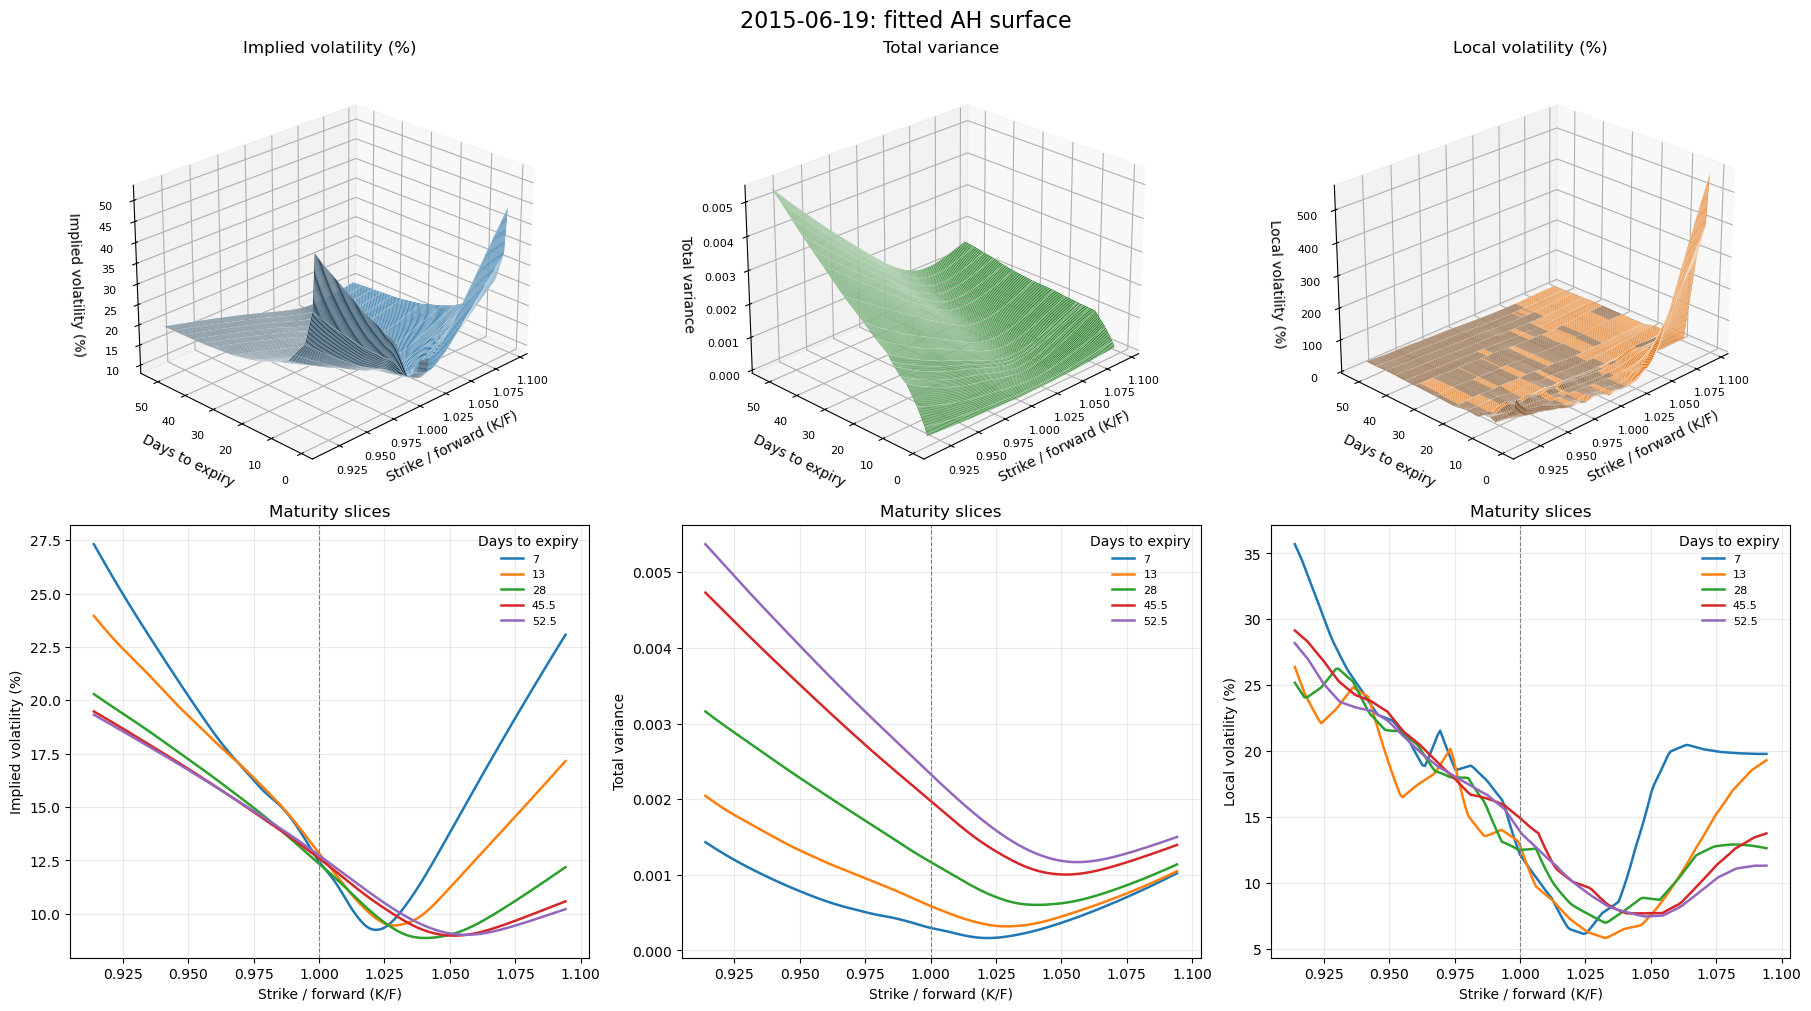

In [3]:
DATE = study.dates[-1] if study and study.dates else None
ROOT = "UNKNOWN"
evidence = None

if DATE:
    manifest = study.dated_table(DATE, "model_manifest")
    display(manifest)
    if (manifest.root.eq(ROOT) & manifest.status.eq("fitted")).any():
        evidence = study.surface_evidence(DATE, ROOT)
        samples = evidence["surface_samples"]
        samples = samples.loc[samples.side.eq("right")].copy()
        times = np.sort(samples["T"].unique())
        y = np.sort(samples["y"].unique())
        days = 365 * times
        moneyness = np.exp(y)
        X, Y = np.meshgrid(moneyness, days)
        slice_indices = np.unique([
            np.abs(days - target).argmin() for target in (7, 14, 30, 45, 60)
        ])
        fields = (
            ("ah_iv", "Implied volatility (%)", 100, "tab:blue"),
            ("ah_w", "Total variance", 1, "tab:green"),
            ("ah_actual_lv", "Local volatility (%)", 100, "tab:orange"),
        )
        fig = plt.figure(figsize=(18, 10), layout="constrained")
        fig.suptitle(f"{DATE}: fitted AH surface", fontsize=16)
        for column, (field, label, scale, color) in enumerate(fields):
            table = samples.pivot(index="T", columns="y", values=field)
            Z = scale * table.reindex(index=times, columns=y).to_numpy(float)
            Z[~np.isfinite(Z)] = np.nan

            ax = fig.add_subplot(2, 3, column + 1, projection="3d")
            ax.plot_surface(
                X, Y, Z, color=color, edgecolor="white", linewidth=0.15,
                rstride=1, cstride=1, antialiased=True, alpha=0.95,
            )
            ax.set(
                xlabel="Strike / forward (K/F)", ylabel="Days to expiry",
                zlabel=label, title=label,
            )
            ax.view_init(elev=25, azim=-135)
            ax.set_box_aspect((1.5, 1.2, 1))
            ax.tick_params(labelsize=8)

            ax2 = fig.add_subplot(2, 3, column + 4)
            for row in slice_indices:
                ax2.plot(moneyness, Z[row], linewidth=1.8, label=f"{days[row]:g}")
            ax2.axvline(1, color="grey", linestyle="--", linewidth=0.8)
            ax2.set(
                xlabel="Strike / forward (K/F)", ylabel=label,
                title="Maturity slices",
            )
            ax2.grid(alpha=0.25)
            ax2.legend(title="Days to expiry", frameon=False, fontsize=8)
        display(fig)
        plt.close(fig)
    else:
        print(f"No fitted AH surface is saved for {DATE}, root {ROOT}.")
else:
    print("No daily surface is available in the selected study.")


In [4]:
if evidence is not None:
    shape = evidence["shape_checks"]
    native = shape.loc[shape.route.eq("AH_native_full_domain")]
    independent = shape.loc[shape.route.eq("quote_total_variance")]
    display(Markdown("**Native AH Price Checks**"))
    display(native[[
        "days", "samples", "increasing_prices", "vertical_spread_violations",
        "negative_butterflies", "intrinsic_shortfalls", "upper_bound_excesses",
        "calendar_violations",
    ]])
    display(Markdown("**Independent Quote Interpolation**"))
    display(independent[[
        "days", "side", "samples", "supported", "admissible",
        "negative_calendar_derivatives", "negative_density_samples",
        "ill_conditioned_denominators", "unstable_derivative_samples",
    ]])
    display(Markdown("**Derivative Comparisons and Density Moments**"))
    display(evidence["numerical_comparison"].fillna("n/a"))
    display(evidence["density_moments"])


**Native AH Price Checks**

,days,samples,increasing_prices,vertical_spread_violations,negative_butterflies,intrinsic_shortfalls,upper_bound_excesses,calendar_violations
1,0.25,8001,0,0,0.0,0.0,0.0,0.0
3,1.00,8001,0,0,0.0,0.0,0.0,0.0
5,3.50,8001,0,0,0.0,0.0,0.0,0.0
8,7.00,8001,0,0,0.0,0.0,0.0,0.0
10,9.00,8001,0,0,0.0,0.0,0.0,0.0
13,11.00,8001,0,0,0.0,0.0,0.0,0.0
15,12.00,8001,0,0,0.0,0.0,0.0,0.0
18,13.00,8001,0,0,0.0,0.0,0.0,0.0
20,17.00,8001,0,0,0.0,0.0,0.0,0.0
23,21.00,8001,0,0,0.0,0.0,0.0,0.0


**Independent Quote Interpolation**

,days,side,samples,supported,admissible,negative_calendar_derivatives,negative_density_samples,ill_conditioned_denominators,unstable_derivative_samples
0,0.25,right,181,0.0,0.0,0.0,0.0,0.0,0.0
2,1.00,right,181,0.0,0.0,0.0,0.0,0.0,0.0
4,3.50,right,181,0.0,0.0,0.0,0.0,0.0,0.0
6,7.00,left,181,0.0,0.0,0.0,0.0,0.0,0.0
7,7.00,right,181,142.0,77.0,0.0,48.0,48.0,59.0
9,9.00,right,181,142.0,82.0,0.0,48.0,48.0,58.0
11,11.00,left,181,142.0,84.0,0.0,45.0,45.0,55.0
12,11.00,right,181,157.0,87.0,3.0,52.0,52.0,63.0
14,12.00,right,181,157.0,92.0,3.0,42.0,42.0,61.0
16,13.00,left,181,157.0,92.0,3.0,49.0,49.0,64.0


**Derivative Comparisons and Density Moments**

,quote_date,root,days,side,ah_chain_comparable,max_ah_chain_variance_difference,max_ah_fd_variance_difference,max_ah_fd_width_change,ah_fd_stable_samples,quote_supported_samples,quote_admissible_samples,max_quote_variance_difference,max_quote_price_difference
0,2015-06-19,UNKNOWN,0.25,right,181,6.729195e-11,0.025008,0.043024,180,0,0,n/a,n/a
1,2015-06-19,UNKNOWN,1.00,right,181,2.179235e-11,0.013920,0.026132,181,0,0,n/a,n/a
2,2015-06-19,UNKNOWN,3.50,right,181,1.432277e-11,0.008330,0.017631,181,0,0,n/a,n/a
3,2015-06-19,UNKNOWN,7.00,left,181,7.617018e-12,0.006062,0.014364,181,0,0,n/a,0.154578
4,2015-06-19,UNKNOWN,7.00,right,181,7.376044e-15,0.000784,0.001192,181,142,77,0.354605,0.154578
5,2015-06-19,UNKNOWN,9.00,right,181,3.536060e-14,0.000425,0.000702,181,142,82,0.593854,0.37092
6,2015-06-19,UNKNOWN,11.00,left,181,2.128853e-14,0.000415,0.000692,181,142,84,0.357971,0.494718
7,2015-06-19,UNKNOWN,11.00,right,181,1.262879e-15,0.003997,0.001026,181,157,87,0.676472,0.494718
8,2015-06-19,UNKNOWN,12.00,right,181,2.053913e-14,0.001203,0.003397,181,157,92,0.681502,0.324122
9,2015-06-19,UNKNOWN,13.00,left,181,1.446065e-14,0.001295,0.003643,181,157,92,0.839694,0.167442


,quote_date,root,days,finite_domain_nodal_mass,finite_domain_nodal_first_moment,report_window_nodal_mass,negative_nodal_densities,zero_or_underflow_nodal_densities
0,2015-06-19,UNKNOWN,0.25,1.0,1.000000,1.000000,0,0
1,2015-06-19,UNKNOWN,1.00,1.0,1.000000,0.999999,0,0
2,2015-06-19,UNKNOWN,3.50,1.0,1.000000,0.999607,0,0
3,2015-06-19,UNKNOWN,7.00,1.0,0.999999,0.997466,0,0
4,2015-06-19,UNKNOWN,9.00,1.0,0.999999,0.995764,0,0
5,2015-06-19,UNKNOWN,11.00,1.0,0.999999,0.993203,0,0
6,2015-06-19,UNKNOWN,12.00,1.0,0.999999,0.992017,0,0
7,2015-06-19,UNKNOWN,13.00,1.0,0.999999,0.989903,0,0
8,2015-06-19,UNKNOWN,17.00,1.0,0.999999,0.984065,0,0
9,2015-06-19,UNKNOWN,21.00,1.0,0.999999,0.978368,0,0


## Historical Hedge Performance

The default comparison holds the same option for five reference sessions and
rebalances its index hedge daily. Candidate and Black hedges use matched option
entries. Positive Gain means lower squared hedge error than Black; negative Gain
means higher squared error.

The comparison includes funding and the chosen execution scenario. Squared
errors are measured around zero, so both dispersion and mean error contribute
to Gain. The tables also report absolute errors and the number of matched
entries.

Interim hedge summaries can cover fewer dates than the daily-model cache. A
path marked `pending_run_prefix` has not reached the end of its holding period
within the saved evaluation. It becomes eligible for evaluation when a later
summary is written. Missing observations and model failures have separate
coverage statuses.


No completed matched comparisons in the saved summary for 5/1, mid.
That summary covers 3 reference dates, with 3,276 pending paths across all schedules and strategies.
Available schedules in this saved summary:


,holding_sessions,rebalance_sessions,scenario
0,1,1,mid
210,1,1,option_spread
420,1,1,option_spread_fee


Check coverage below. pending_run_prefix paths await a later evaluation; other statuses describe exclusions or failures.


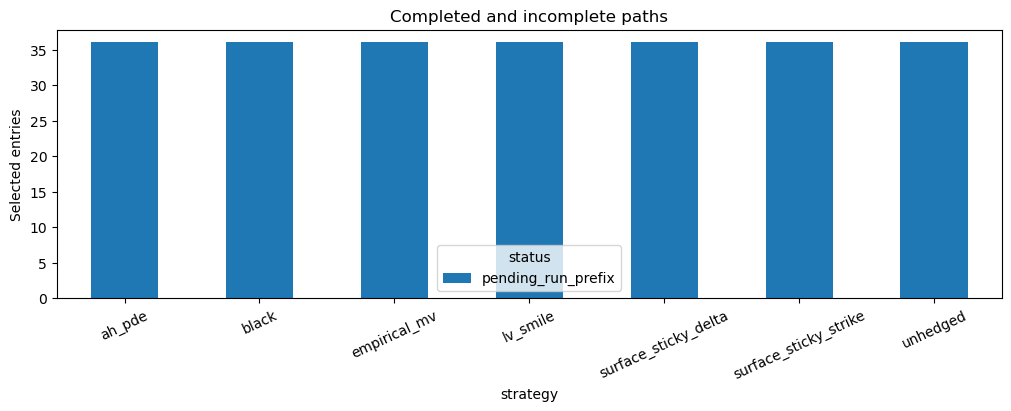

In [5]:
HOLDING = 5
REBALANCE = 1
SCENARIO = "mid"
BLOCK = 20

gains = None
selected = None
if study and study.summary_ready:
    gains = study.table("gain_summary")
    selected = gains.loc[
        gains.holding_sessions.eq(HOLDING) & gains.rebalance_sessions.eq(REBALANCE)
        & gains.scenario.eq(SCENARIO) & gains.dimension.eq("overall")
    ]
    if selected.empty:
        print(f"No completed matched comparisons in the saved summary for {HOLDING}/{REBALANCE}, {SCENARIO}.")
        if summary_audit:
            print(f"That summary covers {summary_audit['processed_reference_dates']:,} reference dates, with {summary_audit['pending_paths']:,} pending paths across all schedules and strategies.")
        if gains.empty:
            print("The saved summary contains no matched gain estimates for any schedule.")
        else:
            print("Available schedules in this saved summary:")
            display(gains[["holding_sessions", "rebalance_sessions", "scenario"]].drop_duplicates())
        print("Check coverage below. pending_run_prefix paths await a later evaluation; other statuses describe exclusions or failures.")
    else:
        display(selected)
        display(study.plot_gains(HOLDING, REBALANCE, SCENARIO, BLOCK))
    display(study.plot_coverage(HOLDING, REBALANCE, SCENARIO))
    plt.close("all")
else:
    print("Historical hedge results are waiting for the runner to write an aggregate summary.")


In [6]:
if gains is not None and selected is not None and not selected.empty:
    breakdown = gains.loc[
        gains.holding_sessions.eq(HOLDING) & gains.rebalance_sessions.eq(REBALANCE)
        & gains.scenario.eq(SCENARIO) & gains.dimension.isin(["maturity_bucket", "moneyness_bucket", "delta_bucket", "year"])
    ]
    if breakdown.empty:
        print("No bucket breakdowns are available for this saved comparison.")
    else:
        display(breakdown)
    common = study.table("common_strategy_gain")
    common = common.loc[
        common.holding_sessions.eq(HOLDING) & common.rebalance_sessions.eq(REBALANCE)
        & common.scenario.eq(SCENARIO)
    ]
    if common.empty:
        print("No common intersection of all strategies is available for this saved comparison.")
    else:
        display(common)
else:
    print("Bucket and common-strategy estimates become available when matched comparisons have been saved.")


Bucket and common-strategy estimates become available when matched comparisons have been saved.


## September and October Development Studies

These saved pilots compare AH PDE delta with Black on one-session option paths.
The table reports each execution scenario separately and uses identical entries
for the two methods. Gain is the percentage reduction in squared hedge error;
it is separate from the improvement in mean absolute error.

The completed market studies gave mixed results: AH reduced RMS error in
September and increased it in October. October's MAE comparison was slightly
favorable despite its higher RMS. That combination suggests a difference in the
larger errors, which the distribution and entry-date plots help examine.

For the selected `SCENARIO`, each bar shows an entry date's contribution to the
month's overall Gain. The bars sum to that Gain, so a large contribution remains
visible even when most dates look unremarkable. The distribution plot shows the
fraction of matched entries below each absolute-error level.

The loading cell uses the original pilot index paths. Missing files are shown
with their expected locations. These are development studies, and their
results do not form an untouched final test set.


,Month,Scenario,Comparisons,Entry dates,AH RMS,Black RMS,Gain (%),MAE improvement
0,2023-09,mid,342,19,2.7404,3.1308,23.3849,0.0340
1,2023-09,option_spread,342,19,3.4240,4.5258,42.7635,0.5260
2,2023-09,option_spread_fee,342,19,3.6172,4.7941,43.0730,0.6011
3,2023-10,mid,390,22,3.5498,3.4501,-5.8608,0.0465
4,2023-10,option_spread,390,22,4.3381,4.2863,-2.4350,-0.1395
5,2023-10,option_spread_fee,390,22,4.4771,4.4719,-0.2340,-0.1421


**Coverage for mid**

,Month,Status,Paths
0,2023-09,compared,342
1,2023-09,sample_end,18
2,2023-10,compared,390


**Calibration and numerical-validation scope**

,Month,Fitted models,Other model records,Validation dates requested,Diagnostic dates loaded
0,2023-09,20,0,0,0
1,2023-10,22,0,5,5


Loaded diagnostic dates describe the sampled validation scope, not independent verification of every entry Greek.


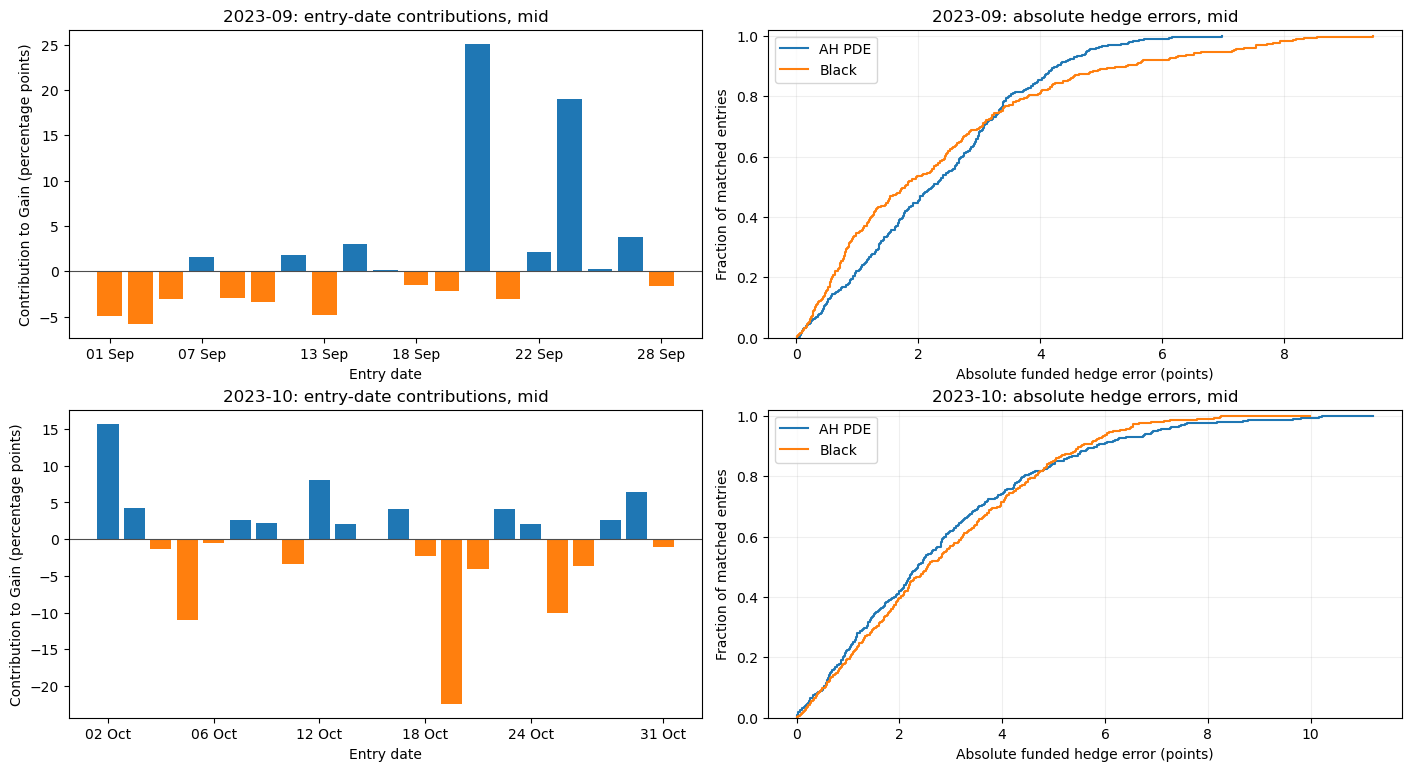

In [7]:
pilot_summary = []
pilot_coverage = []
pilot_validation = []
pilot_selected = {}
for month, saved in pilots.items():
    pairs = saved.frames["paired_results"]
    require(pairs, ["scenario", "entry_id", "quote_date", "ah_net_pnl", "black_net_pnl"],
            f"{month} paired results", ["scenario", "entry_id"])
    if not np.isfinite(pairs[["ah_net_pnl", "black_net_pnl"]].to_numpy()).all():
        raise ValueError(f"Nonfinite paired hedge errors in {month}.")
    for scenario, group in pairs.groupby("scenario", sort=True):
        ah = group.ah_net_pnl.to_numpy()
        black = group.black_net_pnl.to_numpy()
        black_sse = black @ black
        pilot_summary.append({
            "Month": month, "Scenario": scenario, "Comparisons": len(group),
            "Entry dates": group.quote_date.nunique(),
            "AH RMS": np.sqrt(np.mean(ah**2)),
            "Black RMS": np.sqrt(np.mean(black**2)),
            "Gain (%)": 100 * (1 - (ah @ ah) / black_sse) if black_sse > 0 else np.nan,
            "MAE improvement": np.mean(abs(black)) - np.mean(abs(ah)),
        })
    current = pairs.loc[pairs.scenario.eq(SCENARIO)].copy()
    if not current.empty:
        pilot_selected[month] = current
    coverage = saved.frames["coverage"]
    for status, group in coverage.loc[coverage.scenario.eq(SCENARIO)].groupby("status", sort=True):
        pilot_coverage.append({"Month": month, "Status": status, "Paths": len(group)})
    compared = coverage.loc[coverage.scenario.eq(SCENARIO) & coverage.status.eq("compared")]
    if set(compared.entry_id) != set(current.entry_id):
        raise ValueError(f"Paired results and compared coverage disagree in {month}.")
    validation = saved.frames["validation_coverage"]
    manifest = saved.frames["model_manifest"]
    pilot_validation.append({
        "Month": month, "Fitted models": int(manifest.status.eq("fitted").sum()),
        "Other model records": int(manifest.status.ne("fitted").sum()),
        "Validation dates requested": int(validation.requested.sum()),
        "Diagnostic dates loaded": int(validation.diagnostics_loaded.sum()),
    })
    saved.verify_unchanged()

if pilot_summary:
    pilot_summary = pd.DataFrame(pilot_summary)
    display(pilot_summary.round(4).fillna("n/a"))
    display(Markdown(f"**Coverage for {SCENARIO}**"))
    display(pd.DataFrame(pilot_coverage))
    display(Markdown("**Calibration and numerical-validation scope**"))
    display(pd.DataFrame(pilot_validation))
    print("Loaded diagnostic dates describe the sampled validation scope, not independent verification of every entry Greek.")
else:
    print("No completed monthly comparisons were found. Check PILOT_INDEXES in the loading cell.")

if pilot_selected:
    fig, axes = plt.subplots(len(pilot_selected), 2, figsize=(14, 3.8 * len(pilot_selected)), squeeze=False, layout="constrained")
    for row, (month, pairs) in enumerate(pilot_selected.items()):
        daily = pairs.assign(
            ah_sse=pairs.ah_net_pnl**2, black_sse=pairs.black_net_pnl**2,
        ).groupby("quote_date")[["ah_sse", "black_sse"]].sum()
        denominator = daily.black_sse.sum()
        ax = axes[row, 0]
        if denominator > 0:
            contributions = 100 * (daily.black_sse - daily.ah_sse) / denominator
            positions = np.arange(len(daily))
            ax.bar(positions, contributions, color=np.where(contributions >= 0, "tab:blue", "tab:orange"))
            ticks = np.unique(np.linspace(0, len(daily) - 1, min(6, len(daily)), dtype=int))
            ax.set_xticks(ticks, pd.to_datetime(daily.index[ticks]).strftime("%d %b"))
            ax.axhline(0, color="0.3", linewidth=0.8)
        else:
            ax.text(0.5, 0.5, "Gain is undefined: Black SSE is zero", ha="center", transform=ax.transAxes)
        ax.set(title=f"{month}: entry-date contributions, {SCENARIO}", xlabel="Entry date", ylabel="Contribution to Gain (percentage points)")
        ax = axes[row, 1]
        for column, label, color in [("ah_net_pnl", "AH PDE", "tab:blue"), ("black_net_pnl", "Black", "tab:orange")]:
            errors = np.sort(abs(pairs[column].to_numpy()))
            ax.step(errors, np.arange(1, len(errors) + 1) / len(errors), where="post", label=label, color=color)
        ax.set(title=f"{month}: absolute hedge errors, {SCENARIO}", xlabel="Absolute funded hedge error (points)", ylabel="Fraction of matched entries", ylim=(0, 1.02))
        ax.legend()
        ax.grid(alpha=0.2)
    display(fig)
    plt.close(fig)


## October Smile and Empirical Hedge Comparison

The expanded October study adds sticky strike, sticky delta, the LV smile
approximation and the empirical MV correction. It uses the same one-session
accounting conventions as the pilot comparison. The table below reads the
saved strategy results; it does not fit new coefficients or recalculate hedges.

The original midpoint study reported positive Gain for empirical MV and the
LV approximation, while AH PDE and sticky delta increased squared error.
Sticky strike changed it only slightly. These are findings from the development
sample. Their persistence across the full history remains an open question.

Read the matched counts and Black RMS beside each Gain. A method with fewer
usable entries has a different comparison sample. The common-entry table
restricts all methods to one intersection. A Gain of -185.53%, for example,
means squared hedge error is about 2.855 times the matched Black error; it is
not a percentage trading loss.


In [8]:
strategy_tables = {}
if strategy_reader:
    for name in ("gain_summary", "common_strategy_gain", "coverage", "mv_fits", "mv_training_membership"):
        strategy_tables[name] = strategy_reader.read_pinned_csv(
            STRATEGY_FOLDER / f"{name}.csv",
            strategy_audit.get("output_sha256", {}).get(f"{name}.csv"),
            {"quote_date": str, "entry_id": str, "fit_id": str, "training_entry_id": str},
        )
    strategy_reader.verify_unchanged()
    names = {
        "ah_pde": "AH PDE", "empirical_mv": "Empirical MV", "lv_smile": "LV smile",
        "surface_sticky_strike": "Sticky strike", "surface_sticky_delta": "Sticky delta",
    }
    columns = ["strategy", "comparisons", "entry_dates", "gain", "rms_net_pnl", "black_rms_net_pnl", "mae_improvement"]
    labels = {
        "strategy": "Strategy", "comparisons": "Comparisons", "entry_dates": "Entry dates",
        "gain": "Gain (%)", "rms_net_pnl": "Strategy RMS", "black_rms_net_pnl": "Matched Black RMS",
        "mae_improvement": "MAE improvement",
    }
    for name, title in [("gain_summary", "Matched candidate/Black entries"), ("common_strategy_gain", "Common entries across all methods")]:
        gains = strategy_tables[name]
        selected_gains = gains.loc[gains.scenario.eq(SCENARIO) & gains.dimension.eq("overall")].copy()
        display(Markdown(f"**{title}: {SCENARIO}**"))
        if selected_gains.empty:
            print("No saved comparisons are available for this intersection and scenario.")
            continue
        require(selected_gains, columns + ["black_sse", "strategy_sse"], title, ["strategy"])
        defined = selected_gains.black_sse.gt(0)
        expected = 1 - selected_gains.loc[defined, "strategy_sse"] / selected_gains.loc[defined, "black_sse"]
        if not np.allclose(selected_gains.loc[defined, "gain"], expected, rtol=1e-10, atol=1e-12):
            raise ValueError("Saved Gain does not agree with its squared-error totals.")
        view = selected_gains[columns].copy()
        view["strategy"] = view.strategy.map(names).fillna(view.strategy)
        view["gain"] *= 100
        display(view.rename(columns=labels).round(4).fillna("n/a"))
    coverage = strategy_tables["coverage"]
    counts = coverage.loc[coverage.scenario.eq(SCENARIO)].groupby(["strategy", "status"]).size().rename("Paths").reset_index()
    counts["strategy"] = counts.strategy.map(names).fillna(counts.strategy)
    display(Markdown(f"**Strategy coverage: {SCENARIO}**"))
    display(counts.rename(columns={"strategy": "Strategy", "status": "Status"}))
else:
    print(f"No saved strategy comparison was found at {STRATEGY_FOLDER}. Set STRATEGY_FOLDER to the existing completed run.")


**Matched candidate/Black entries: mid**

,Strategy,Comparisons,Entry dates,Gain (%),Strategy RMS,Matched Black RMS,MAE improvement
0,AH PDE,390,22,-5.8608,3.5498,3.4501,0.0465
33,Empirical MV,390,22,25.2902,2.9821,3.4501,0.4828
66,LV smile,386,22,11.4352,3.2498,3.4533,0.2713
99,Sticky delta,386,22,-185.5318,5.8352,3.4533,-2.1566
132,Sticky strike,386,22,0.1284,3.4511,3.4533,0.0032


**Common entries across all methods: mid**

,Strategy,Comparisons,Entry dates,Gain (%),Strategy RMS,Matched Black RMS,MAE improvement
0,AH PDE,386,22,-6.7124,3.5673,3.4533,0.0212
33,Empirical MV,386,22,24.6779,2.9970,3.4533,0.4603
66,LV smile,386,22,11.4352,3.2498,3.4533,0.2713
99,Sticky delta,386,22,-185.5318,5.8352,3.4533,-2.1566
132,Sticky strike,386,22,0.1284,3.4511,3.4533,0.0032


**Strategy coverage: mid**

,Strategy,Status,Paths
0,AH PDE,compared,390
1,black,compared,390
2,Empirical MV,compared,390
3,LV smile,compared,386
4,LV smile,unresolved,4
5,Sticky delta,compared,386
6,Sticky delta,unresolved,4
7,Sticky strike,compared,386
8,Sticky strike,stencil_disagreement,4


### Empirical Estimation Checks

The empirical model fits the quadratic correction separately for calls and
puts using completed past observations. Warm-up and conditioning failures
remain part of its coverage. The checks below inspect the saved membership
list and confirm that training endpoints precede their prediction timestamps.
They also compare the listed membership counts with the recorded training rows.

The coefficients act together through the predicted delta correction. A change
in one coefficient does not by itself establish a change in the market
relationship. Timestamp checks establish the ordering of the saved records;
they do not independently reconstruct the regression from raw quotes.


Inspected 44 fit records and 11,226 listed training observations.
All listed training endpoints precede prediction; membership counts agree with the saved fits.


,kind,status,Fits
0,call,ready,22
1,put,ready,22


,kind,Fits,Minimum training dates,Maximum training dates,Maximum condition number
0,call,22,19,39,61.9652
1,put,22,19,39,53.7872


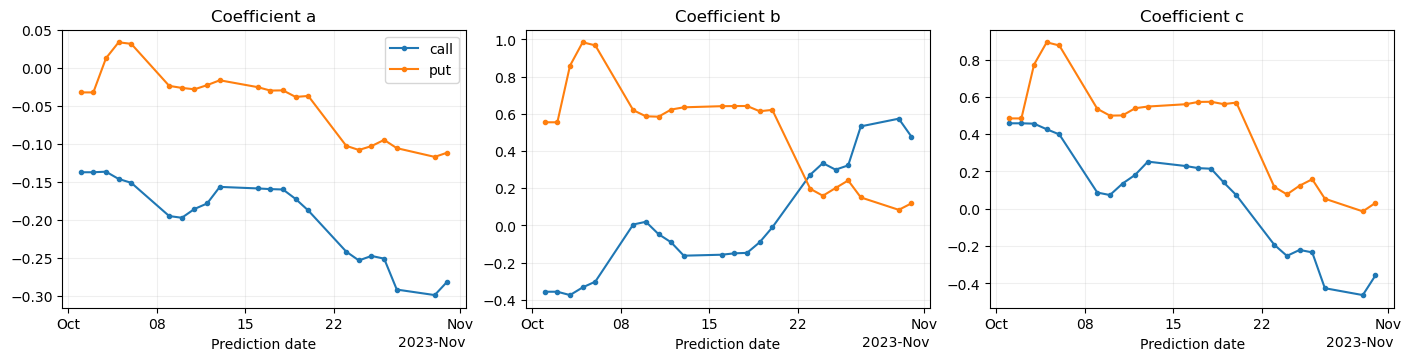

In [9]:
if strategy_tables:
    fits = strategy_tables["mv_fits"]
    membership = strategy_tables["mv_training_membership"]
    require(fits, ["fit_id", "kind", "status", "prediction_timestamp", "training_rows"], "Empirical fits", ["fit_id"])
    require(membership, ["fit_id", "training_entry_id", "training_endpoint"], "Training membership", ["fit_id", "training_entry_id"])
    members = membership.merge(fits[["fit_id", "prediction_timestamp"]], on="fit_id", how="left", validate="many_to_one", indicator=True)
    if not members._merge.eq("both").all():
        raise ValueError("Training membership references an unknown fit.")
    for timestamps in (membership.training_endpoint, fits.prediction_timestamp):
        if any(pd.Timestamp(value).tzinfo is None for value in timestamps):
            raise ValueError("Training and prediction timestamps must include a timezone.")
    endpoints = pd.to_datetime(members.training_endpoint, utc=True)
    predictions = pd.to_datetime(members.prediction_timestamp, utc=True)
    if (endpoints.isna() | predictions.isna() | endpoints.ge(predictions)).any():
        raise ValueError("A listed training endpoint is not strictly earlier than prediction.")
    recorded_counts = membership.groupby("fit_id").size().reindex(fits.fit_id, fill_value=0).to_numpy()
    if not np.array_equal(recorded_counts, fits.training_rows.to_numpy()):
        raise ValueError("Training membership counts disagree with the saved fit records.")
    print(f"Inspected {len(fits):,} fit records and {len(membership):,} listed training observations.")
    if membership.empty:
        print("No listed training observations are available for the endpoint-order check.")
    else:
        print("All listed training endpoints precede prediction; membership counts agree with the saved fits.")
    display(fits.groupby(["kind", "status"]).size().rename("Fits").reset_index())
    ready_fits = fits.loc[fits.status.eq("ready")].copy()
    if not ready_fits.empty:
        require(ready_fits, ["a", "b", "c", "quote_date", "available_dates", "scaled_condition_number"], "Ready empirical fits")
        if not np.isfinite(ready_fits[["a", "b", "c", "scaled_condition_number"]].to_numpy()).all():
            raise ValueError("A ready empirical fit contains nonfinite coefficients or conditioning.")
        scope = ready_fits.groupby("kind").agg(
            Fits=("fit_id", "size"),
            Minimum_training_dates=("available_dates", "min"),
            Maximum_training_dates=("available_dates", "max"),
            Maximum_condition_number=("scaled_condition_number", "max"),
        ).reset_index()
        display(scope.rename(columns=lambda name: name.replace("_", " ")).round(4))
        fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), layout="constrained")
        for kind, group in ready_fits.groupby("kind"):
            group = group.sort_values("quote_date")
            for ax, coefficient in zip(axes, ["a", "b", "c"]):
                ax.plot(pd.to_datetime(group.quote_date), group[coefficient], marker=".", label=kind)
                ax.set(title=f"Coefficient {coefficient}", xlabel="Prediction date")
                ax.grid(alpha=0.2)
        for ax in axes:
            locator = mdates.AutoDateLocator(minticks=3, maxticks=6)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
        axes[0].legend()
        display(fig)
        plt.close(fig)
    else:
        print("No ready empirical fits were saved in this run.")
    strategy_reader.verify_unchanged()


## Black–Scholes and CEV Simulation Controls

Black–Scholes and square-root CEV provide known prices, Greeks and exact
simulated transitions. This experiment isolates the effects of hedge frequency,
PDE approximation and account calculations from market-model mismatch.

The frequency plots compare analytical delta hedges with and without fees. The tables below report analytical and PDE convergence results. The funded cost and mean-P&L plots show how trading costs change the outcome as rebalancing becomes more frequent. Convergence slopes, PDE checks and scalar-ledger comparisons are reported below the figures.


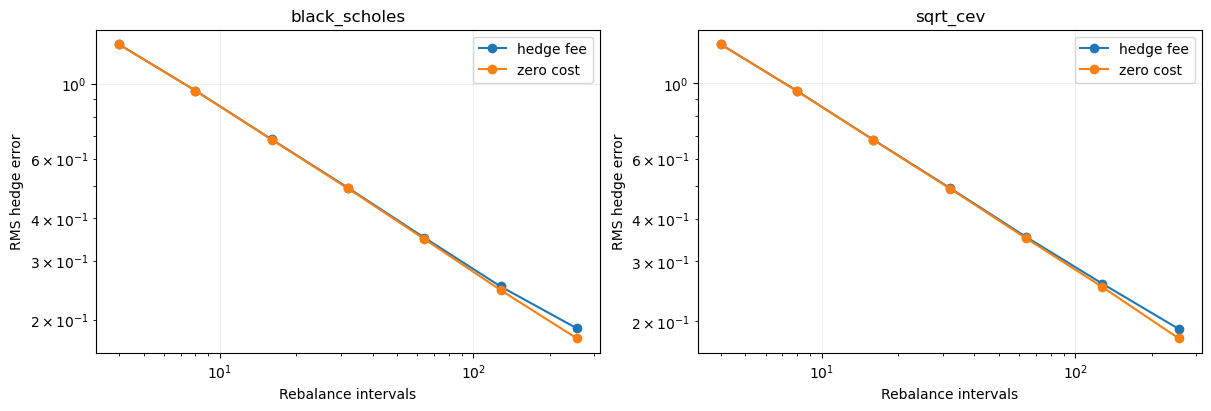

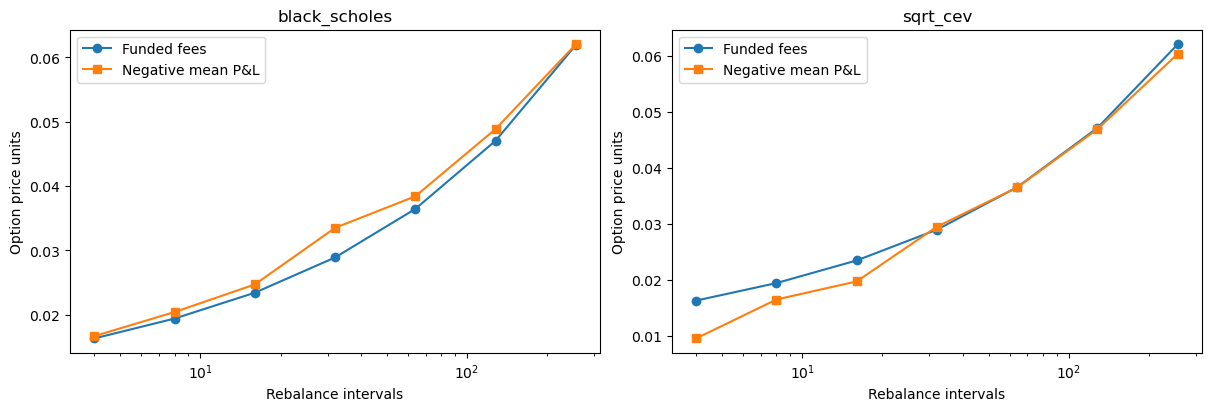

,model,strike,kind,strategy,frequencies,asymptotic_reference,status,paths,slope,slope_ci_low,slope_ci_high
0,black_scholes,95.0,call,analytical_delta,32;64;128;256,-0.5,estimated,20000,-4.846861e-01,-4.929425e-01,-4.759163e-01
1,black_scholes,95.0,call,pde_delta,32;64;128;256,-0.5,estimated,20000,-4.846865e-01,-4.936961e-01,-4.749830e-01
2,black_scholes,95.0,call,entry_iv_black,32;64;128;256,NaN,estimated,20000,-4.846861e-01,-4.937425e-01,-4.740133e-01
3,black_scholes,95.0,call,misspecified_black,32;64;128;256,NaN,estimated,20000,-2.034755e-01,-2.080884e-01,-1.986310e-01
4,black_scholes,95.0,call,unhedged,32;64;128;256,NaN,estimated,20000,1.662679e-15,1.379708e-15,2.523434e-15
5,black_scholes,100.0,call,analytical_delta,32;64;128;256,-0.5,estimated,20000,-4.928920e-01,-5.017459e-01,-4.846593e-01
6,black_scholes,100.0,call,pde_delta,32;64;128;256,-0.5,estimated,20000,-4.928834e-01,-5.000851e-01,-4.852169e-01
7,black_scholes,100.0,call,entry_iv_black,32;64;128;256,NaN,estimated,20000,-4.928920e-01,-5.005038e-01,-4.844988e-01
8,black_scholes,100.0,call,misspecified_black,32;64;128;256,NaN,estimated,20000,-2.636160e-01,-2.683569e-01,-2.592461e-01
9,black_scholes,100.0,call,unhedged,32;64;128;256,NaN,estimated,20000,1.687530e-15,1.251174e-15,1.994747e-15


,model,strike,case,calendar_time,remaining_years,time_steps,intervals,half_width,steps_per_day,control_spots,max_price_error,max_price_change_vs_base,max_delta_error,max_delta_change_vs_base,max_gamma_error,max_gamma_change_vs_base,status
0,black_scholes,95.0,base,0.000000,0.164384,2050,1600,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000018,0.000000e+00,0.000004,0.000000e+00,0.000002,0.000000e+00,finite
1,black_scholes,95.0,base,0.082192,0.082192,2050,1600,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000022,0.000000e+00,0.000007,0.000000e+00,0.000002,0.000000e+00,finite
2,black_scholes,95.0,base,0.163741,0.000642,2050,1600,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000354,0.000000e+00,0.000100,0.000000e+00,0.005511,0.000000e+00,finite
3,black_scholes,95.0,space_coarse,0.000000,0.164384,2050,800,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000134,1.298956e-04,0.000022,1.868748e-05,0.000004,2.860366e-06,finite
4,black_scholes,95.0,space_coarse,0.082192,0.082192,2050,800,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000191,1.847416e-04,0.000046,3.912355e-05,0.000020,1.783912e-05,finite
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,sqrt_cev,105.0,time_fine,0.082192,0.082192,3956,1600,1.0,64.0,90.0;100.0;105.0;110.00000000000001,0.000024,1.457515e-07,0.000007,3.168090e-08,0.000002,9.817884e-09,finite
86,sqrt_cev,105.0,time_fine,0.163741,0.000642,3956,1600,1.0,64.0,90.0;100.0;105.0;110.00000000000001,0.000097,2.194785e-04,0.000038,6.488961e-06,0.002845,1.934577e-03,finite
87,sqrt_cev,105.0,domain_wide,0.000000,0.164384,2050,2400,1.5,32.0,90.0;100.0;105.0;110.00000000000001,0.000021,8.881784e-15,0.000003,2.320366e-14,0.000002,3.785375e-13,finite
88,sqrt_cev,105.0,domain_wide,0.082192,0.082192,2050,2400,1.5,32.0,90.0;100.0;105.0;110.00000000000001,0.000024,2.664535e-15,0.000007,3.774758e-15,0.000002,1.933731e-13,finite


,model,strike,kind,strategy,scenario,intervals,status,path_id,scalar_net_pnl,batch_net_pnl,difference,scalar_max_reconciliation,ledger_file
0,black_scholes,95.0,call,analytical_delta,zero_cost,16,verified,0,0.556328,0.556328,1.847411e-13,1.887379e-14,representative_ledgers/black_scholes_95_call_a...
1,black_scholes,95.0,call,analytical_delta,zero_cost,16,verified,1,0.049160,0.049160,2.842171e-13,2.860906e-14,representative_ledgers/black_scholes_95_call_a...
2,black_scholes,95.0,call,analytical_delta,zero_cost,16,verified,2,1.021323,1.021323,1.989520e-13,3.119727e-14,representative_ledgers/black_scholes_95_call_a...
3,black_scholes,95.0,call,analytical_delta,hedge_fee,16,verified,0,0.529195,0.529195,1.847411e-13,3.072542e-14,representative_ledgers/black_scholes_95_call_a...
4,black_scholes,95.0,call,analytical_delta,hedge_fee,16,verified,1,0.026907,0.026907,3.268497e-13,3.010266e-14,representative_ledgers/black_scholes_95_call_a...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,sqrt_cev,105.0,put,pde_delta,zero_cost,16,verified,1,0.379610,0.379610,-1.563194e-13,3.952394e-14,representative_ledgers/sqrt_cev_105_put_pde_de...
140,sqrt_cev,105.0,put,pde_delta,zero_cost,16,verified,2,0.038725,0.038725,-2.131628e-13,1.711131e-14,representative_ledgers/sqrt_cev_105_put_pde_de...
141,sqrt_cev,105.0,put,pde_delta,hedge_fee,16,verified,0,-1.316242,-1.316242,4.884981e-14,8.593820e-15,representative_ledgers/sqrt_cev_105_put_pde_de...
142,sqrt_cev,105.0,put,pde_delta,hedge_fee,16,verified,1,0.357348,0.357348,-2.131628e-13,1.978452e-14,representative_ledgers/sqrt_cev_105_put_pde_de...


In [10]:
if simulation:
    display(simulation.plot_frequency())
    display(simulation.plot_costs())
    plt.close("all")
    display(simulation.table("convergence_slopes"))
    display(simulation.table("pde_checks"))
    display(simulation.table("scalar_ledger_checks"))
else:
    print(f"No saved simulation tables were found in {SIMULATION_FOLDER}. Set the path to an existing run.")


## Interpretation and Limitations

A lower overall squared error does not establish that a hedge performs better
across all contracts or market periods. RMS error, MAE, mean P&L and coverage
describe different aspects of the result. Maturity, moneyness and year
breakdowns show where a difference is concentrated, while common-entry
comparisons account for unequal strategy coverage.

Entry-date block resampling allows for dependence from overlapping holding
periods. Sensitivity to block length and the available number of entry dates
limits how precisely a Gain estimate can be interpreted.

The synthetic index hedge, constant rates and assumed settlement clock define
the historical experiment. The results measure hedge errors under those
conventions. The [data preparation](../docs/data.md),
[methodology](../docs/methods.md), [validation](../docs/validation.md) and
[assumptions](../docs/assumptions.md) describe the inputs, calculations and their
limits. [Results and interpretation](../docs/results.md) records the completed
studies while the full-history evaluation is running.
